# Qwen Stateless Free-Form Judge

**Design principle:**
Each config is judged in a completely independent API call.
Qwen receives the question + data + config fresh every time.
No shared history, no primed mental model, no bias from previous configs.

**Why stateless is fairer:**
- Multi-turn priming causes Qwen to form one mental picture of the ideal chart
  and compare everything else against it — that is biased evaluation.
- Stateless evaluation means each config stands on its own merits.
- Results are reproducible and defensible.

**Output per config:**
- verdict: PASS / FAIL
- score: 0.0 – 1.0
- reasoning: Qwen's own free-form explanation
- suggested_improvement: concrete fix if FAIL

In [1]:
# CELL 1 — Imports
import os, sys, re, json, csv, time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from openai import OpenAI

In [2]:
# CELL 2 — Project root + data

CANDIDATE_ROOTS = [
    "/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch",
    "/Users/srujanakadambari/Desktop/data-to-visual/data-to-visual-nicos-branch",
    "../data-to-visual-nicos-branch",
    "..",
    ".",
]

PROJECT_ROOT = None
for p in CANDIDATE_ROOTS:
    p = Path(p).expanduser().resolve()
    if (p / "retrieve_data.py").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("retrieve_data.py not found. Check CANDIDATE_ROOTS.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from retrieve_data import retrieve_data

MD_TABLE = retrieve_data(None, type="test")

QUESTION = (
    "Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? "
    "Provide a detailed analysis of the data based of total earnings and "
    "provide a comprehensive visualization supporting your analysis."
)

print("Project root :", PROJECT_ROOT)
print("Table length :", len(MD_TABLE), "chars")

Project root : /Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch
Table length : 3405 chars


In [3]:
# CELL 3 — Paths

CONFIG_DIR  = PROJECT_ROOT / "FINAL FOLDER" / "master_run_results" / "configs"
RESULTS_DIR = CONFIG_DIR.parent
OUT_DIR     = RESULTS_DIR / "qwen_stateless_judge"
VERDICT_DIR = OUT_DIR / "verdicts"
OUT_DIR.mkdir(parents=True, exist_ok=True)
VERDICT_DIR.mkdir(parents=True, exist_ok=True)

JUDGE_CSV = OUT_DIR / "qwen_stateless_verdicts.csv"

config_files = sorted(CONFIG_DIR.glob("*.json"))

print("CONFIG_DIR   :", CONFIG_DIR)
print("Exists       :", CONFIG_DIR.exists())
print("Config files :", len(config_files))
print("Sample files :")
for f in config_files[:5]:
    print(" -", f.name)

CONFIG_DIR   : /Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/FINAL FOLDER/master_run_results/configs
Exists       : True
Config files : 180
Sample files :
 - S0_run01.json
 - S0_run02.json
 - S0_run03.json
 - S0_run04.json
 - S0_run05.json


In [4]:
# CELL 4 — Qwen client

client = OpenAI(
    base_url="http://hal9000.skim.th-owl.de:11877/v1",
    api_key="dummy",
    timeout=300,
)

QWEN_MODEL = "Qwen3.6-27B"

# Guide-recommended fast-mode params
FAST_PARAMS = dict(
    temperature=0.7,
    top_p=0.8,
    presence_penalty=1.5,
    extra_body={
        "top_k": 20,
        "chat_template_kwargs": {"enable_thinking": False},
    },
)

print("Model :", QWEN_MODEL)

Model : Qwen3.6-27B


In [5]:
# CELL 5 — Helpers

def parse_scenario_run(path):
    stem = Path(path).stem
    m = re.search(r"^(SA\d+|S\d+b?|S\d+)_run(\d+)", stem, flags=re.IGNORECASE)
    if m:
        return m.group(1).upper(), int(m.group(2))
    m = re.search(r"(SA\d+|S\d+b?|S\d+)", stem, flags=re.IGNORECASE)
    scenario = m.group(1).upper() if m else stem
    m2 = re.search(r"run(\d+)", stem, flags=re.IGNORECASE)
    run = int(m2.group(1)) if m2 else -1
    return scenario, run


def load_config(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def extract_verdict(text):
    """Extract JSON verdict from Qwen response. Strips <think> blocks if any."""
    if not text:
        raise ValueError("Empty response")
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()
    text = text.replace("```json", "").replace("```", "").strip()
    if "{" in text:
        text = text[text.index("{"):]
    if "}" in text:
        text = text[:text.rindex("}")+1]
    return json.loads(text)


print("Helpers ready.")

Helpers ready.


In [6]:
# CELL 6 — Core judge function (stateless)
#
# Each call is completely independent.
# Qwen receives question + data + config fresh every time.
# No shared history. No primed mental model. No bias.

SYSTEM_PROMPT = """You are an expert visualization evaluator.
You will receive a business question, a source data table, and one JSON chart configuration.

Your job: judge whether this specific chart configuration correctly answers this specific question.

Reason freely and honestly in your own words:
- Does the chart type make sense for what the question is asking?
- Is the right data being shown — correct metric, segment, time range?
- Would a business user actually get the answer they need from this chart?
- Is anything misleading, missing, or wrong?

Do not follow a fixed checklist. Think for yourself.

Return ONLY valid JSON — no markdown, no explanation outside the JSON:
{
  "verdict": "PASS" or "FAIL",
  "score": number between 0.0 and 1.0,
  "reasoning": "your honest free-form explanation of why this chart passes or fails",
  "suggested_improvement": "one concrete actionable fix if FAIL, or null if PASS"
}"""


def judge_config(question, md_table, cfg, scenario, run):
    """
    Stateless judge — completely fresh call per config.
    Returns (verdict_dict, latency_seconds)
    """
    user_msg = f"""BUSINESS QUESTION:
{question}

SOURCE DATA TABLE:
{md_table}

CHART CONFIGURATION TO EVALUATE ({scenario} run {run}):
{json.dumps(cfg, indent=2, ensure_ascii=False)}

Does this chart correctly answer the business question above?
Give your honest assessment and return your JSON verdict."""

    t0 = time.perf_counter()

    resp = client.chat.completions.create(
        model=QWEN_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_msg},
        ],
        max_tokens=600,
        **FAST_PARAMS,
    )

    latency = time.perf_counter() - t0
    raw     = resp.choices[0].message.content or ""

    if not raw:
        raise ValueError("Qwen returned empty content")

    verdict = extract_verdict(raw)
    verdict.setdefault("verdict",              "ERROR")
    verdict.setdefault("score",                "")
    verdict.setdefault("reasoning",            "")
    verdict.setdefault("suggested_improvement", None)

    return verdict, latency


print("Judge function ready.")

Judge function ready.


In [7]:
# CELL 7 — Quick sanity check before full run
# Judges the first config only — verify output looks right before running all 180

test_cfg_path = config_files[0]
test_scenario, test_run = parse_scenario_run(test_cfg_path)
test_cfg = load_config(test_cfg_path)

print(f"Testing: {test_scenario} run {test_run}")
print(f"Config keys: {list(test_cfg.keys()) if isinstance(test_cfg, dict) else type(test_cfg)}")
print()

test_verdict, test_latency = judge_config(QUESTION, MD_TABLE, test_cfg, test_scenario, test_run)

print(f"Verdict  : {test_verdict['verdict']}")
print(f"Score    : {test_verdict['score']}")
print(f"Latency  : {test_latency:.1f}s")
print()
print("Reasoning:")
print(test_verdict['reasoning'])
print()
if test_verdict.get('suggested_improvement') not in (None, 'None', 'null', ''):
    print("Suggested fix:")
    print(test_verdict['suggested_improvement'])

Testing: S0 run 1
Config keys: ['titlename', 'charttype', 'xlabel', 'ylabel', 'y_ticks', 'x_ticks', 'x_tick_label', 'y_tick_label', 'x_lim', 'y_lim', 'annotations', 'data']

Verdict  : FAIL
Score    : 0.4
Latency  : 5.7s

Reasoning:
The business question explicitly asks for the revenue ('Wieviel Umsatz') in the years 2021 to 2024 and requests a detailed analysis based on 'total earnings'. The provided chart displays monthly revenue broken down by year (lines per year), but it does not show the aggregated annual totals which are required to answer 'how much revenue' was generated in those specific years. A user looking at this chart would have to manually sum up 12 data points for each of the four lines to get the answer, which is inefficient and prone to error. Furthermore, while the prompt mentions 'Segment JVA', the source table lacks a segment column, so we assume the data is already filtered; however, the visualization format fails to provide the requested summary metric (annual to

In [9]:
# CELL 8 — Run judge on all configs (resume-safe)

FIELDS = [
    "scenario", "run", "config_file", "timestamp",
    "judge_model", "judge_latency_s",
    "verdict", "score",
    "reasoning",
    "suggested_improvement",
    "error",
]

if not JUDGE_CSV.exists():
    with open(JUDGE_CSV, "w", newline="", encoding="utf-8") as f:
        csv.DictWriter(f, fieldnames=FIELDS).writeheader()

# Load already-completed rows (resume-safe)
done = set()
try:
    df_done = pd.read_csv(JUDGE_CSV)
    for _, r in df_done.iterrows():
        if str(r.get("error", "")) == "" and str(r.get("verdict", "")) in ["PASS", "FAIL"]:
            done.add((str(r["scenario"]), int(r["run"])))
    print(f"Already done : {len(done)}")
except Exception:
    print("Starting fresh.")

total     = len(config_files)
attempted = 0

for idx, cfg_path in enumerate(config_files, start=1):
    scenario, run = parse_scenario_run(cfg_path)

    if (scenario, run) in done:
        print(f"[{idx:3d}/{total}] {scenario}_run{run:02d} skip")
        continue

    print(f"[{idx:3d}/{total}] {scenario}_run{run:02d} judging...", end=" ", flush=True)

    row = {
        "scenario":            scenario,
        "run":                 run,
        "config_file":         str(cfg_path),
        "timestamp":           time.strftime("%Y-%m-%dT%H:%M:%S"),
        "judge_model":         QWEN_MODEL,
        "judge_latency_s":     "",
        "verdict":             "ERROR",
        "score":               "",
        "reasoning":           "",
        "suggested_improvement": "",
        "error":               "",
    }

    try:
        cfg = load_config(cfg_path)

        if isinstance(cfg, dict) and "_error" in cfg:
            raise ValueError("Config has _error — pipeline failure.")

        verdict, latency = judge_config(QUESTION, MD_TABLE, cfg, scenario, run)

        row.update({
            "judge_latency_s":       round(latency, 3),
            "verdict":               verdict["verdict"],
            "score":                 verdict["score"],
            "reasoning":             verdict["reasoning"],
            "suggested_improvement": verdict.get("suggested_improvement") or "",
            "error":                 "",
        })

        # Save individual verdict JSON
        with open(VERDICT_DIR / f"{scenario}_run{run:02d}.json", "w", encoding="utf-8") as f:
            json.dump(verdict, f, indent=2, ensure_ascii=False)

        # Live print with reasoning
        print(f"{row['verdict']} score={row['score']} ({latency:.1f}s)")
        print(f"   → {verdict['reasoning'][:200]}")
        if verdict.get('suggested_improvement') not in (None, 'None', 'null', ''):
            print(f"   Fix: {str(verdict['suggested_improvement'])[:150]}")
        print()
        attempted += 1

    except Exception as e:
        row["error"] = type(e).__name__ + ": " + str(e)
        print(f"ERROR: {row['error'][:120]}")
        print()

    with open(JUDGE_CSV, "a", newline="", encoding="utf-8") as f:
        csv.DictWriter(f, fieldnames=FIELDS).writerow(row)

print(f"\nDone. Attempted this session : {attempted}")
print(f"CSV : {JUDGE_CSV}")

Already done : 0
[  1/180] S0_run01 judging... FAIL score=0.4 (4.8s)
   → The chart fails to answer the core part of the business question: 'Wieviel Umsatz hatte Teckentrup...'. The question asks for the revenue amount (a total or aggregated figure) for the years 2021-2024.
   Fix: Change the visualization to display the **total annual revenue** for each year (2021, 2022, 2023, 2024), likely using a column/bar chart or a line cha

[  2/180] S0_run02 judging... FAIL score=0.3 (4.5s)
   → The chart fails to answer the core part of the business question: 'Wieviel Umsatz hatte Teckentrup...'. The question asks for the revenue amount (total earnings), implying a need for annual aggregates
   Fix: Change the chart type to a bar chart showing the summed revenue per year (2021-2024). Alternatively, keep the line chart but add clear annotations or 

[  3/180] S0_run03 judging... FAIL score=0.4 (4.9s)
   → The chart displays monthly revenue trends for each year (2021-2024), which provides contex

In [10]:
# CELL 9 — Summary table by scenario

df = pd.read_csv(JUDGE_CSV)
df["score"]           = pd.to_numeric(df["score"],           errors="coerce")
df["judge_latency_s"] = pd.to_numeric(df["judge_latency_s"], errors="coerce")

print(f"Total rows : {len(df)}")
print(f"PASS       : {(df['verdict']=='PASS').sum()}")
print(f"FAIL       : {(df['verdict']=='FAIL').sum()}")
print(f"ERROR      : {(df['verdict']=='ERROR').sum()}")
print()

summary = df.groupby("scenario").agg(
    runs           = ("run",             "count"),
    pass_count     = ("verdict",         lambda x: (x=="PASS").sum()),
    fail_count     = ("verdict",         lambda x: (x=="FAIL").sum()),
    pass_rate      = ("verdict",         lambda x: round((x=="PASS").mean()*100, 1)),
    mean_score     = ("score",           lambda x: round(x.mean(), 3)),
    median_score   = ("score",           lambda x: round(x.median(), 3)),
    mean_latency_s = ("judge_latency_s", lambda x: round(x.mean(), 2)),
).reset_index().sort_values("pass_rate", ascending=False)

display(summary)

summary_path = OUT_DIR / "qwen_stateless_summary.csv"
summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

Total rows : 200
PASS       : 26
FAIL       : 172
ERROR      : 2



,scenario,runs,pass_count,fail_count,pass_rate,mean_score,median_score,mean_latency_s
3,S3,10,10,0,100.0,1.000,1.00,2.91
9,S7,10,3,7,30.0,0.490,0.40,4.84
12,SA1,10,2,8,20.0,0.500,0.40,4.55
5,S4B,10,2,8,20.0,0.420,0.30,5.24
6,S5,10,2,8,20.0,0.460,0.40,5.10
0,S0,20,2,18,10.0,0.440,0.40,4.46
1,S1,20,2,18,10.0,0.450,0.40,4.47
2,S2,10,1,9,10.0,0.430,0.40,4.58
10,S8,10,1,9,10.0,0.420,0.40,6.19
17,SA6,10,1,9,10.0,0.400,0.35,4.98


Saved: /Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/FINAL FOLDER/master_run_results/qwen_stateless_judge/qwen_stateless_summary.csv


In [ ]:
# CELL 10 — Visualization: Pass Rate + Mean Score by Scenario

df = pd.read_csv(JUDGE_CSV)
df["score"] = pd.to_numeric(df["score"], errors="coerce")

summary = df.groupby("scenario").agg(
    pass_rate  = ("verdict", lambda x: (x=="PASS").mean() * 100),
    mean_score = ("score",   "mean"),
).reset_index().sort_values("pass_rate", ascending=False)

scenarios = summary["scenario"].tolist()
x = range(len(scenarios))

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

bars = ax1.bar(x, summary["pass_rate"], color="steelblue", alpha=0.75)
line, = ax2.plot(x, summary["mean_score"], color="darkorange",
                  marker="o", linewidth=2, markersize=7)

# Annotate bars
for bar, val in zip(bars, summary["pass_rate"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{val:.0f}%",
        ha="center", va="bottom", fontsize=8, color="steelblue"
    )

ax1.set_xticks(list(x))
ax1.set_xticklabels(scenarios, rotation=45, ha="right", fontsize=9)
ax1.set_ylabel("Pass Rate (%)", color="steelblue")
ax1.set_ylim(0, 120)
ax2.set_ylabel("Mean Score (0–1)", color="darkorange")
ax2.set_ylim(0, 1.2)
ax2.tick_params(axis="y", labelcolor="darkorange")

handles = [
    mpatches.Patch(color="steelblue", alpha=0.75, label="Pass Rate (%)"),
    plt.Line2D([0],[0], color="darkorange", marker="o", linewidth=2, label="Mean Score"),
]
ax1.legend(handles=handles, loc="upper right")
ax1.set_title(
    f"Qwen Stateless Judge ({QWEN_MODEL}): Pass Rate & Mean Score by Scenario",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()

fig_path = OUT_DIR / "qwen_stateless_pass_rate.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

In [11]:
# CELL 11 — Inspect full reasoning for any scenario + run

INSPECT_SCENARIO = "S0"   # change this
INSPECT_RUN      = 1      # change this

f = VERDICT_DIR / f"{INSPECT_SCENARIO}_run{INSPECT_RUN:02d}.json"

if not f.exists():
    print(f"Not found: {f}")
else:
    with open(f, encoding="utf-8") as fh:
        v = json.load(fh)

    print("=" * 55)
    print(f"  {INSPECT_SCENARIO}  Run {INSPECT_RUN}")
    print("=" * 55)
    print(f"Verdict  : {v['verdict']}")
    print(f"Score    : {v['score']}")
    print()
    print("Qwen's Reasoning:")
    print("-" * 55)
    print(v.get("reasoning", "(none)"))
    print()
    imp = v.get("suggested_improvement")
    if imp not in (None, "None", "null", ""):
        print("Suggested Improvement:")
        print("-" * 55)
        print(imp)

  S0  Run 1
Verdict  : FAIL
Score    : 0.4

Qwen's Reasoning:
-------------------------------------------------------
The chart fails to answer the core part of the business question: 'Wieviel Umsatz hatte Teckentrup...'. The question asks for the revenue amount (a total or aggregated figure) for the years 2021-2024. The provided chart displays *monthly* revenue trends over time. While it contains the raw data points, it does not explicitly show the annual totals required to directly answer 'how much revenue' was generated in those specific years. A user would have to manually sum up 48 different data points across four lines to get the answer, which is inefficient and prone to error. Furthermore, the annotations highlight individual monthly peaks/troughs rather than the yearly performance metrics requested. A bar chart showing annual totals or a line chart with cumulative/annual markers would be appropriate.

Suggested Improvement:
-----------------------------------------------------

In [ ]:
# CELL 12 — PASS / FAIL examples for thesis

df = pd.read_csv(JUDGE_CSV)
pd.set_option("display.max_colwidth", 350)

cols = ["scenario", "run", "verdict", "score", "reasoning", "suggested_improvement"]

print("=== PASS Examples ===")
display(df[df["verdict"]=="PASS"][cols].head(5))

print("\n=== FAIL Examples ===")
display(df[df["verdict"]=="FAIL"][cols].head(5))

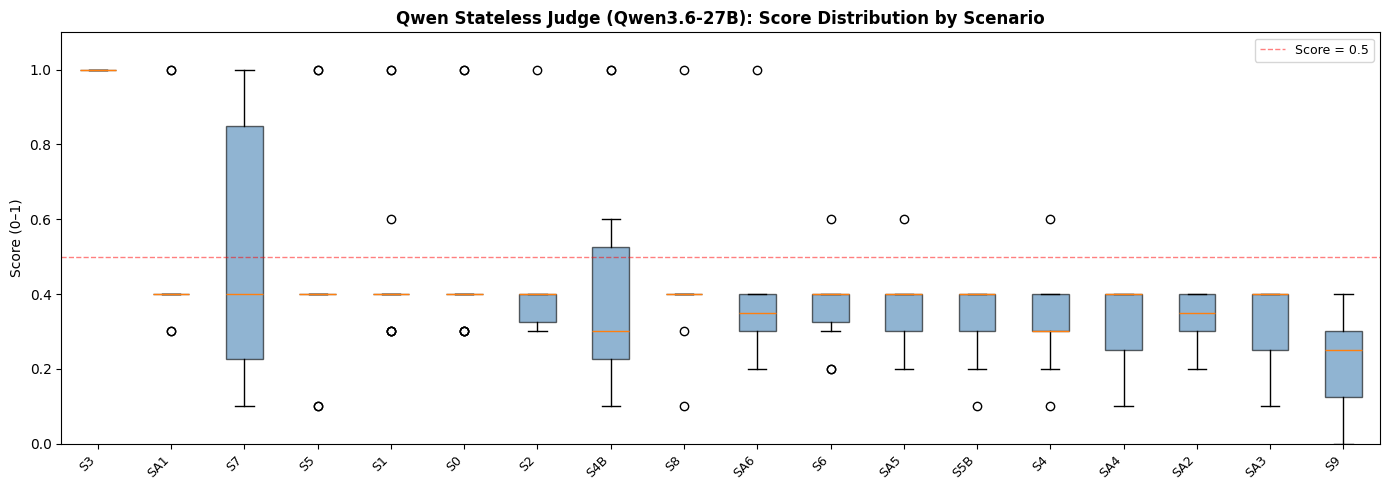

Saved: /Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/FINAL FOLDER/master_run_results/qwen_stateless_judge/qwen_stateless_score_distribution.png


In [12]:
# CELL 13 — Score distribution by scenario (box plot)

df = pd.read_csv(JUDGE_CSV)
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df = df[df["verdict"].isin(["PASS", "FAIL"])]

scenarios_ordered = (
    df.groupby("scenario")["score"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

data_by_scenario = [df[df["scenario"]==s]["score"].dropna().values for s in scenarios_ordered]

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(data_by_scenario, patch_artist=True, notch=False)

for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)

ax.set_xticks(range(1, len(scenarios_ordered)+1))
ax.set_xticklabels(scenarios_ordered, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Score (0–1)")
ax.set_ylim(0, 1.1)
ax.set_title(
    f"Qwen Stateless Judge ({QWEN_MODEL}): Score Distribution by Scenario",
    fontsize=12, fontweight="bold"
)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, alpha=0.5, label="Score = 0.5")
ax.legend(fontsize=9)
plt.tight_layout()

fig_path = OUT_DIR / "qwen_stateless_score_distribution.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

## Thesis-ready wording

> To evaluate the output quality of each architecture scenario, I employed a stateless Qwen-as-Judge approach using the Qwen3.6-27B model hosted locally at TH OWL.
>
> Each chart configuration was evaluated in a completely independent API call. For every config, Qwen received the original business question, the full source data table, and the generated JSON chart configuration as a fresh context — with no shared history, no prior conversation, and no pre-formed mental model of what the correct chart should look like.
>
> This stateless design was a deliberate methodological choice. A multi-turn approach — where Qwen is primed with the data once and then judges all configs in sequence — risks anchoring bias: the model forms one internal reference chart and compares all subsequent configs against it, regardless of their individual merits. Stateless evaluation ensures each config is judged independently and on its own terms.
>
> For each configuration, Qwen returned a PASS or FAIL verdict, a confidence score between 0 and 1, a free-form reasoning statement in its own words explaining why the chart does or does not answer the question, and a concrete suggested improvement for failed configurations. This produces transparent, human-readable justifications that directly address the evaluation question: not just whether a config passed, but why.